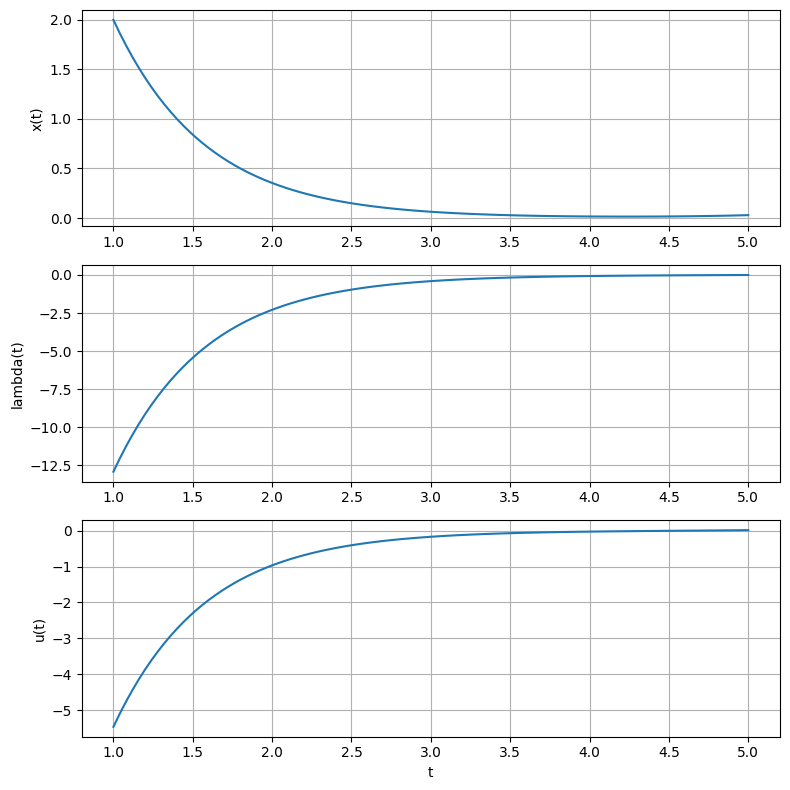

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

t = np.linspace(1, 5, 101)

def ode(t, y):
    x = y[0]
    lam = y[1]

    dxdt = 1.5 * x + 0.5 * lam
    dlamdt = 1.5 * x - 1.5 * lam

    return np.vstack((dxdt, dlamdt))


def bc(ya, yb):
    return np.array([
        ya[0] - 2,
        yb[1]
    ])

y_guess = np.zeros((2, t.size))
y_guess[0] = 2

sol = solve_bvp(ode, bc, t, y_guess)

x = sol.y[0]
lam = sol.y[1]
u = 0.5 * (x + lam)

plt.figure(figsize=(8,8))

plt.subplot(3,1,1)
plt.plot(sol.x, x)
plt.ylabel("x(t)")
plt.grid()

plt.subplot(3,1,2)
plt.plot(sol.x, lam)
plt.ylabel("lambda(t)")
plt.grid()

plt.subplot(3,1,3)
plt.plot(sol.x, u)
plt.ylabel("u(t)")
plt.xlabel("t")
plt.grid()

plt.tight_layout()
plt.show()

u_vals = u

Convergence: -451191.05928981927
Convergence: -119112.23570399781
Convergence: -87648.07605555684
Convergence: -64495.3478606939
Convergence: -47458.54062176964
Convergence: -34922.1000583351
Convergence: -25697.229470995502
Convergence: -18909.159370669084
Convergence: -13914.195457550819
Convergence: -10238.678834328195
Convergence: -7534.070216013612
Convergence: -5543.8988936903215
Convergence: -4079.4423119216126
Convergence: -3001.8300200400936
Convergence: -2208.874963488199
Convergence: -1625.3833622428344
Convergence: -1196.024288344976
Convergence: -880.0827838827028
Convergence: -647.5989718236108
Convergence: -476.52704203205934
Convergence: -350.64470681335604
Convergence: -258.0148853133783
Convergence: -189.85374248004774
Convergence: -139.69774177559952
Convergence: -102.7907255182672
Convergence: -75.63290133208841
Convergence: -55.6489663155167
Convergence: -40.943898044795226
Convergence: -30.1232547291579
Convergence: -22.16094407512906
Convergence: -16.301921732067

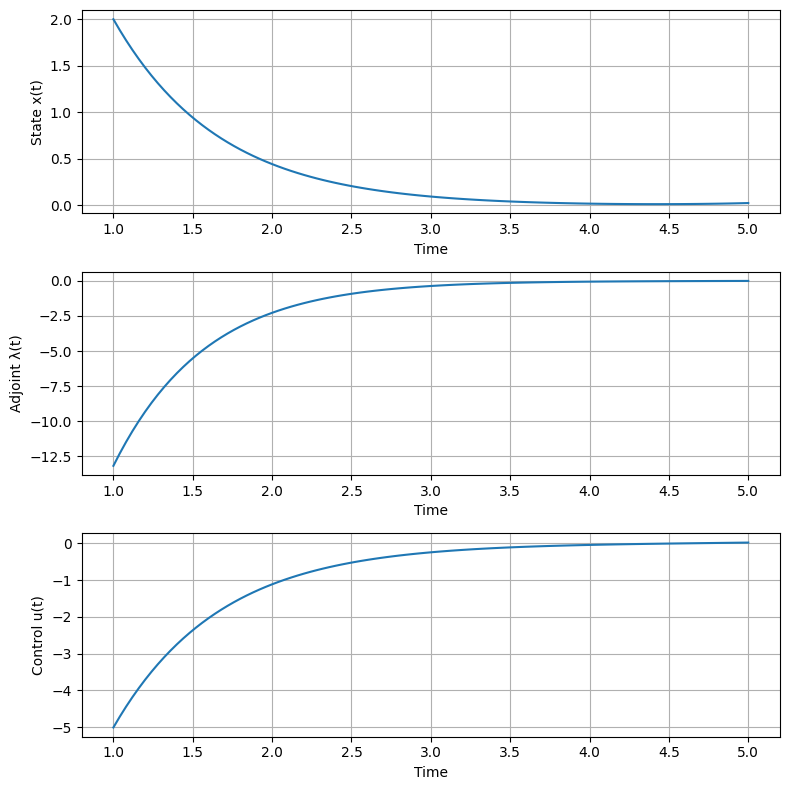

In [33]:
import numpy as np
import matplotlib.pyplot as plt

x0 = 2         
t0 = 1
tf = 5

delta = 0.0001
N = 100

t = np.linspace(t0, tf, N + 1)
h = (tf - t0) / N

u_k = np.zeros(N + 1)
x_k = np.zeros(N + 1)
lambda_k = np.zeros(N + 1)

x_k[0] = x0
lambda_k[-1] = 0  

converged = -1

while converged < 0:

    u_old = u_k.copy()
    x_old = x_k.copy()
    lambda_old = lambda_k.copy()

    for i in range(N):

        k1 = x_k[i] + u_k[i]
        k2 = (x_k[i] + 0.5 * h * k1) + 0.5 * (u_k[i] + u_k[i+1])
        k3 = (x_k[i] + 0.5 * h * k2) + 0.5 * (u_k[i] + u_k[i+1])
        k4 = (x_k[i] + h * k3) + u_k[i+1]

        x_k[i+1] = x_k[i] + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)

    for i in range(N):

        j = N - i

        k1 = 1.5 * (x_k[j] - lambda_k[j])

        k2 = 1.5 * (
            0.5 * (x_k[j] + x_k[j-1])
            - (lambda_k[j] - 0.5 * h * k1)
        )

        k3 = 1.5 * (
            0.5 * (x_k[j] + x_k[j-1])
            - (lambda_k[j] - 0.5 * h * k2)
        )

        k4 = 1.5 * (
            x_k[j-1]
            - (lambda_k[j] - h * k3)
        )

        lambda_k[j-1] = lambda_k[j] - (h / 6) * (k1 + 2*k2 + 2*k3 + k4)

    u_new = 0.5 * (x_k + lambda_k)


    u_k =  0.0001 * u_new + 0.9999 * u_old

    tol_u = delta * np.sum(np.abs(u_k)) - np.sum(np.abs(u_k - u_old))

    tol_x = delta * np.sum(np.abs(x_k)) - np.sum(np.abs(x_k - x_old))

    tol_lambda = delta * np.sum(np.abs(lambda_k)) - np.sum(np.abs(lambda_k - lambda_old))

    converged = min(tol_u, tol_x, tol_lambda)
    print("Convergence:", converged)

plt.figure(figsize=(8, 8))

plt.subplot(3, 1, 1)
plt.plot(t, x_k)
plt.xlabel('Time')
plt.ylabel('State x(t)')
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t, lambda_k)
plt.xlabel('Time')
plt.ylabel('Adjoint λ(t)')
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t, u_k)
plt.xlabel('Time')
plt.ylabel('Control u(t)')
plt.grid()

plt.tight_layout()
plt.show()